# General notebook preparation: Libaries and Datasets

At the beginning, the basic libaries that we work with need to be imported. That includes pandas for data read out, matplot libary for basic plotting, numpy for numeric operations, seaborn for advanced plotting and scipy stats for statistical calculations.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as stats
from pathlib import Path

In [ ]:
ATAC_path_pfiltered = Path('data') / 'ATAC_pfiltered.csv'
ATAC_pfiltered = pd.read_csv(ATAC_pfiltered)
ATAC_pfiltered.head()

In [ ]:
ATAC_path_Tgd = Path('data') / 'ATAC_seq_gd_anot.csv'
ATAC_Tgd = pd.read_csv(ATAC_path_Tgd)
ATAC_Tgd.head()

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,MPP4.135+.BM,preT.DN1.Th,...,preT.DN2b.Th,preT.DN3.Th,T.DN4.Th,Tgd.g1.1+d1.24a+.Th,Tgd.g2+d1.24a+.Th,Tgd.g2+d17.24a+.Th,Tgd.Sp,Tgd.g1.1+d1.LN,Tgd.g2+d1.LN,Tgd.g2+d17.LN
0,ImmGenATAC1219.peak_3,chr1,3120109,0.07,10.80,1.0,NaN,NaN,0.11,0.40,...,0.11,0.10,0.35,0.11,0.76,0.53,1.46,0.11,0.12,0.86
1,ImmGenATAC1219.peak_4,chr1,3121485,0.15,3.02,1.0,NaN,NaN,0.11,0.46,...,0.47,0.10,0.58,0.11,0.29,0.53,0.51,0.11,0.70,0.13
2,ImmGenATAC1219.peak_5,chr1,3372787,0.03,1.31,NaN,NaN,NaN,0.11,0.77,...,1.34,1.69,0.34,1.39,1.58,3.16,0.51,0.99,0.12,0.73
3,ImmGenATAC1219.peak_6,chr1,3399217,0.06,2.39,1.0,NaN,NaN,1.58,0.77,...,0.47,1.02,0.10,1.33,0.10,1.48,0.15,0.11,1.26,0.73
4,ImmGenATAC1219.peak_7,chr1,3400115,0.44,2.57,1.0,NaN,NaN,0.11,0.40,...,0.47,0.10,0.58,1.33,1.27,1.11,0.51,2.86,0.70,0.73


In [ ]:
RNA_seq = pd.read_csv('data/mmc2.csv')
RNA_seq = RNA_seq.set_index("Unnamed: 0")  # Gennamen als Index setzen

Tgd_cells = [
    "MPP4.135+.BM",
    "preT.DN1.Th",
    "preT.DN2a.Th",
    "preT.DN2b.Th",
    "preT.DN3.Th",
    "T.DN4.Th",
    "Tgd.g1.1+d1.24a+.Th",
    "Tgd.g2+d1.24a+.Th",
    "Tgd.g2+d17.24a+.Th",
    "Tgd.Sp",
    "Tgd.g1.1+d1.LN",
    "Tgd.g2+d1.LN",
    "Tgd.g2+d17.LN"
]

RNA_Tgd = RNA_seq[Tgd_cells].copy()
RNA_Tgd.head()


,MPP4.135+.BM,preT.DN1.Th,preT.DN2a.Th,preT.DN2b.Th,preT.DN3.Th,T.DN4.Th,Tgd.g1.1+d1.24a+.Th,Tgd.g2+d1.24a+.Th,Tgd.g2+d17.24a+.Th,Tgd.Sp,Tgd.g1.1+d1.LN,Tgd.g2+d1.LN,Tgd.g2+d17.LN
Unnamed: 0,,,,,,,,,,,,,
0610005C13Rik,1.021812,1.022363,1.389747,1.024819,1.024482,1.026430,1.023995,1.167561,1.024819,1.023995,1.025543,1.024819,1.023995
0610007P14Rik,204.298358,162.641117,206.945221,209.187788,198.421365,215.056475,150.742022,174.031477,115.930664,136.200789,108.850425,102.701399,137.925015
0610009B22Rik,76.418169,68.070719,82.468806,89.769337,57.661619,76.399214,47.775227,44.980534,53.461136,42.439750,28.755395,21.517647,29.122837
0610009L18Rik,16.947354,15.450717,13.573968,14.427620,8.249482,1.683173,8.554990,8.781962,29.156630,8.937625,10.815319,10.202163,9.033355
0610009O20Rik,186.261464,160.246297,125.475307,155.928005,120.692893,118.433597,94.062684,113.600798,102.445617,79.315094,84.643541,106.186930,86.383381


In [ ]:
meta_cols = ["TSS", "genes.within.100Kb", "_-log10_bestPvalue", "Included.in.systematic.analysis",
             "ImmGenATAC1219.peakID", "chrom", "Summit", "mm10.60way.phastCons_scores"]
signal_cols_all = [col for col in ATAC_pfiltered.columns 
                   if col not in meta_cols 
                   and col in RNA_seq.columns] #alle Zelltypen Spaltennamen in ATAC, 
#ohne meta_cols und nur, wenn in ATAC, aber als liste und
signal_cols_all

signal_cols_tgd = Tgd_cells 

## <h1> 1.2 Enhancer vs Promoter (Accessibility signatures)

<h2> Preparing promoter vs enhancer dataset 

In [ ]:
ATAC_enhancers = ATAC_pfiltered[ATAC_pfiltered["TSS"].isnull()]
ATAC_enhancers

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,LTHSC.34-.BM,LTHSC.34+.BM,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
2,ImmGenATAC1219.peak_3,chr1,3120109,0.07,10.80,1.0,NaN,NaN,2.36,0.10,...,0.87,0.54,2.72,0.95,0.11,63.38,8.92,1.33,1.04,0.11
3,ImmGenATAC1219.peak_4,chr1,3121485,0.15,3.02,1.0,NaN,NaN,0.41,0.10,...,0.44,1.83,0.66,0.11,0.92,13.50,0.98,1.28,1.04,0.11
4,ImmGenATAC1219.peak_5,chr1,3372787,0.03,1.31,NaN,NaN,NaN,0.41,0.10,...,0.44,0.10,0.66,1.79,0.51,0.92,0.75,1.33,1.61,4.50
5,ImmGenATAC1219.peak_6,chr1,3399217,0.06,2.39,1.0,NaN,NaN,2.36,1.64,...,1.34,0.29,0.23,0.89,0.11,0.53,1.40,0.90,2.87,9.09
6,ImmGenATAC1219.peak_7,chr1,3400115,0.44,2.57,1.0,NaN,NaN,0.41,0.10,...,0.87,1.93,0.59,0.11,1.39,2.58,0.75,2.30,2.34,11.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
512588,ImmGenATAC1219.peak_512589,chrY,90811728,0.00,2.33,1.0,NaN,Erdr1,0.41,7.41,...,4.98,4.47,2.83,4.93,4.92,5.13,9.13,2.21,6.53,6.11
512589,ImmGenATAC1219.peak_512590,chrY,90812084,0.00,3.12,1.0,NaN,Erdr1,2.36,8.79,...,4.03,4.07,5.87,5.36,3.99,7.12,3.57,2.64,5.59,3.64
512590,ImmGenATAC1219.peak_512591,chrY,90812450,0.00,3.99,1.0,NaN,Erdr1,4.37,8.79,...,3.81,3.34,4.27,6.73,5.53,7.21,5.96,5.17,6.53,6.11
512591,ImmGenATAC1219.peak_512592,chrY,90812906,0.00,3.21,1.0,NaN,Erdr1,0.41,7.41,...,4.28,5.55,4.15,6.88,7.16,6.21,8.75,6.83,8.14,4.64


In [ ]:
ATAC_promoters = ATAC_pfiltered[-ATAC_pfiltered["TSS"].isnull()]
ATAC_promoters

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,LTHSC.34-.BM,LTHSC.34+.BM,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
20,ImmGenATAC1219.peak_21,chr1,3671437,0.72,2.02,1.0,Xkr4,Xkr4,0.41,3.68,...,2.53,0.10,0.11,1.87,0.92,4.97,2.62,2.64,2.83,17.14
139,ImmGenATAC1219.peak_140,chr1,4785675,0.41,15.87,1.0,Mrpl15,"Mrpl15,Lypla1,Tcea1",9.93,20.06,...,21.99,24.19,21.76,22.06,20.80,33.25,23.63,20.90,13.30,22.38
145,ImmGenATAC1219.peak_146,chr1,4807877,0.47,25.12,1.0,Lypla1,"Mrpl15,Lypla1,Tcea1",29.54,42.40,...,26.85,17.69,41.52,42.24,42.23,32.82,31.65,38.34,26.68,33.27
157,ImmGenATAC1219.peak_158,chr1,4857752,0.12,45.65,1.0,Tcea1,"Mrpl15,Lypla1,Tcea1",115.42,141.25,...,80.17,108.52,85.43,79.55,92.80,133.71,85.20,101.38,137.79,129.55
159,ImmGenATAC1219.peak_160,chr1,4858351,0.02,7.78,1.0,Tcea1,"Mrpl15,Lypla1,Tcea1",4.37,6.07,...,10.55,11.20,10.07,10.37,9.80,8.34,8.76,17.31,8.39,11.08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
512467,ImmGenATAC1219.peak_512468,chrX_GL456233_random,39222,0.32,73.75,1.0,Vamp7,"Vamp7,Spry3",57.63,42.40,...,37.95,58.81,61.00,38.21,37.03,63.17,48.63,61.16,82.32,48.00
512477,ImmGenATAC1219.peak_512478,chrX_GL456233_random,159627,0.12,16.28,1.0,Tmlhe,"Spry3,Tmlhe",22.66,21.83,...,3.12,2.21,9.63,0.47,1.75,16.68,8.32,13.71,29.25,5.34
512506,ImmGenATAC1219.peak_512507,chrY,1010556,0.18,13.45,1.0,Eif2s3y,"Eif2s3y,Tspy-ps",12.99,11.79,...,21.53,20.30,17.67,20.86,16.23,9.28,24.00,12.94,11.58,18.65
512522,ImmGenATAC1219.peak_512523,chrY,1245808,0.18,18.59,1.0,Uty,"Uty,Ddx3y",19.40,25.33,...,34.26,34.61,21.57,23.95,24.12,30.97,36.01,30.23,38.30,35.58


<h2> Calculating mean and median values (promoter vs enhancer)

In [ ]:
mean_promoters = ATAC_promoters.iloc[:,8:].mean(axis=1) #Mittelwert jedem Signalpeak über alle Zellen hinweg
mean_promoters.mean() #


np.float64(26.801848038378665)

In [ ]:
median_promoters = ATAC_promoters.iloc[:,8:].median(axis=1) #Mittelwert jedem Signalpeak über alle Zellen hinweg
median_promoters.median() #

np.float64(16.315)

In [ ]:
mean_enhancers = ATAC_enhancers.iloc[:,8:].mean(axis=1)
mean_enhancers.mean()

np.float64(4.241589833922086)

In [ ]:
median_enhancers = ATAC_enhancers.iloc[:,8:].median(axis=1)
median_enhancers.median()

np.float64(1.455)

**Mean ATAC readout signal: Enhancers vs promoters** <p>
The signal peaks that were identified as promoters/TSS show a way higher mean signal across all celltypes than the enhancers (26.801848038378665 vs 4.241589833922086). The median shows a similar trend. To proof whether the mean or the median are more accurate, one needs to take a look at promoter vs enhancer signal distributions and things such as the standard derivation and variance.

<h2> Plotting enhancer vs promoter

<Axes: xlabel='DC.4+.Sp', ylabel='Count'>

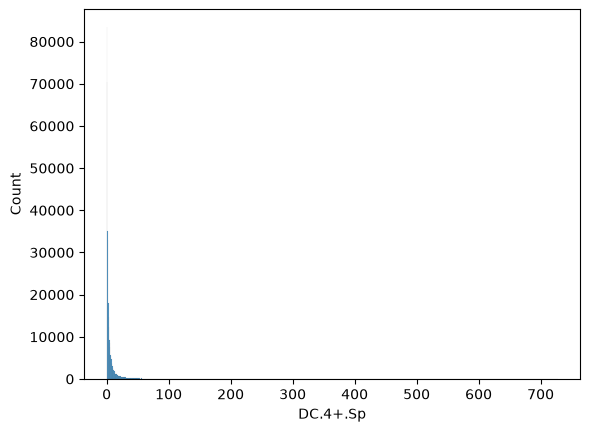

In [ ]:
sns.histplot(data=ATAC_pfiltered.iloc[:,8:], x= "DC.4+.Sp" )

<Axes: xlabel='DC.4+.Sp', ylabel='Count'>

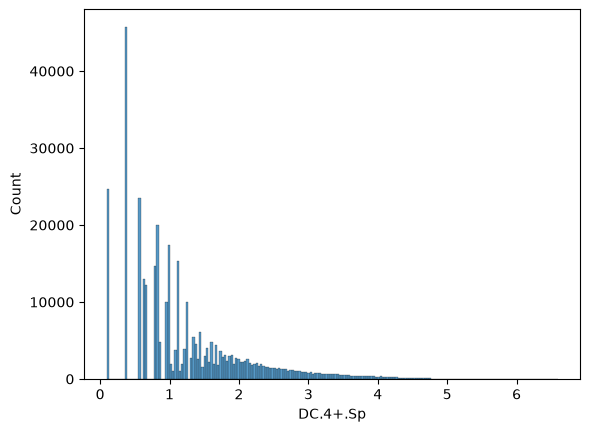

In [ ]:
sns.histplot(data=log_ATAC_pfiltered.iloc[:,8:], x= "DC.4+.Sp" )

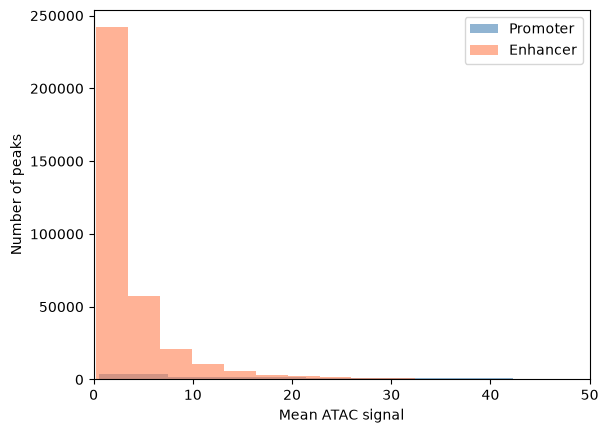

In [ ]:
plt.hist(mean_promoters, bins=100, alpha=0.6, label='Promoter', color='steelblue')
plt.hist(mean_enhancers, bins=100, alpha=0.6, label='Enhancer', color='coral')
plt.xlim(0, 50) 
plt.xlabel('Mean ATAC signal')
plt.ylabel('Number of peaks')
plt.legend()

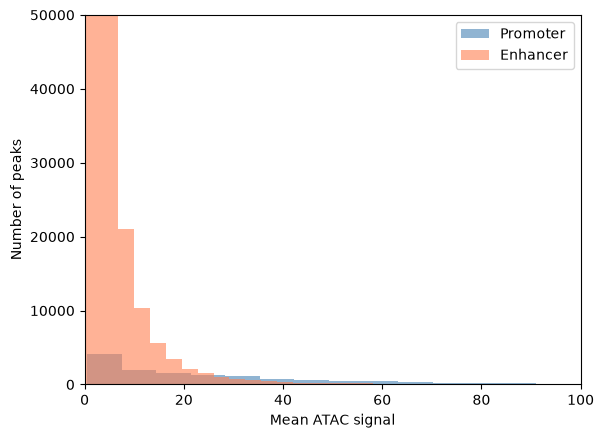

In [ ]:
plt.hist(mean_promoters, bins=100, alpha=0.6, label='Promoter', color='steelblue')
plt.hist(mean_enhancers, bins=100, alpha=0.6, label='Enhancer', color='coral')
plt.xlim(0, 100) 
plt.ylim(0, 50000)
plt.xlabel('Mean ATAC signal')
plt.ylabel('Number of peaks')
plt.legend()

In [ ]:
ATAC_pfiltered_extended = ATAC_pfiltered.copy() 
#ich erstelle mir einen erweiterten Datensatz, der neben dem normalen ATAC_pfiltered dataframe 
#noch weitere spalten mit den means, medians, stds und cvs enthält...
ATAC_pfiltered_extended["mean_signal"] = ATAC_pfiltered.iloc[:,8:].mean(axis=1)
ATAC_pfiltered_extended["median_signal"] = ATAC_pfiltered.iloc[:,8:].median(axis=1)
ATAC_pfiltered_extended["std_signal"] = ATAC_pfiltered.iloc[:,8:].std(axis=1)
ATAC_pfiltered_extended["cv_signal"] = ATAC_pfiltered_extended["std_signal"]/ATAC_pfiltered_extended["mean_signal"]

ATAC_pfiltered_extended["peak_type"] = np.where(
    ATAC_pfiltered_extended["TSS"].notna(), "Promoter", "Enhancer"
)
ATAC_pfiltered_extended[["peak_type", "mean_signal", "median_signal", "std_signal", "cv_signal"]]


,peak_type,mean_signal,median_signal,std_signal,cv_signal
2,Enhancer,1.521000,0.495,6.716484,4.415834
3,Enhancer,0.874556,0.530,1.533709,1.753701
4,Enhancer,0.882111,0.630,0.816587,0.925719
5,Enhancer,1.096556,0.785,1.218798,1.111478
6,Enhancer,0.944556,0.680,1.262417,1.336520
...,...,...,...,...,...
512588,Enhancer,5.823889,4.955,3.648828,0.626528
512589,Enhancer,5.526444,4.705,4.053177,0.733415
512590,Enhancer,6.936111,5.775,4.887909,0.704705
512591,Enhancer,6.995111,6.440,4.386282,0.627050


Text(0.5, 1.0, 'CV of Signal')

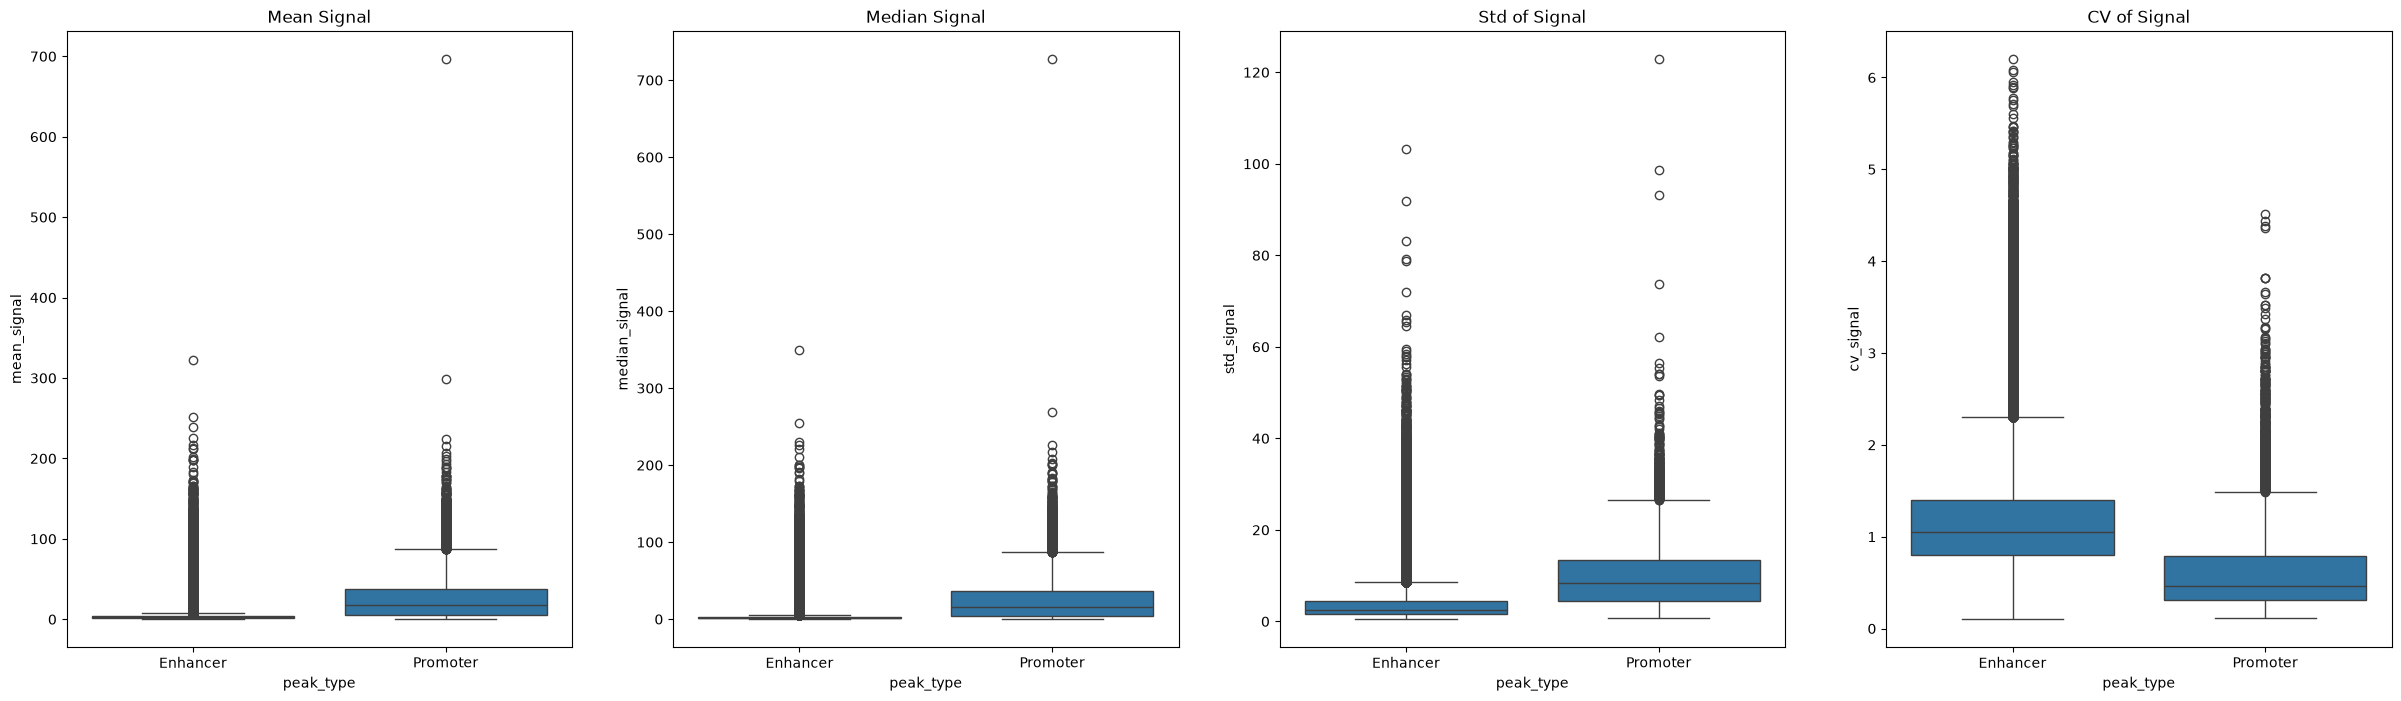

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(30, 8))
sns.boxplot(data=ATAC_pfiltered_extended, x="peak_type", y="mean_signal", ax=axes[0])
axes[0].set_title("Mean Signal")
sns.boxplot(data=ATAC_pfiltered_extended, x="peak_type", y="median_signal", ax=axes[1])
axes[1].set_title("Median Signal")
sns.boxplot(data=ATAC_pfiltered_extended, x="peak_type", y="std_signal", ax=axes[2])
axes[2].set_title("Std of Signal")
sns.boxplot(data=ATAC_pfiltered_extended, x="peak_type", y="cv_signal",  ax=axes[3])
axes[3].set_title("CV of Signal")

C:\Users\lobe-\AppData\Local\Temp\ipykernel_24908\3476802171.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ATAC_pfiltered_extended, x='peak_type', y='mean_signal',
C:\Users\lobe-\AppData\Local\Temp\ipykernel_24908\3476802171.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ATAC_pfiltered_extended, x='peak_type', y='cv_signal',


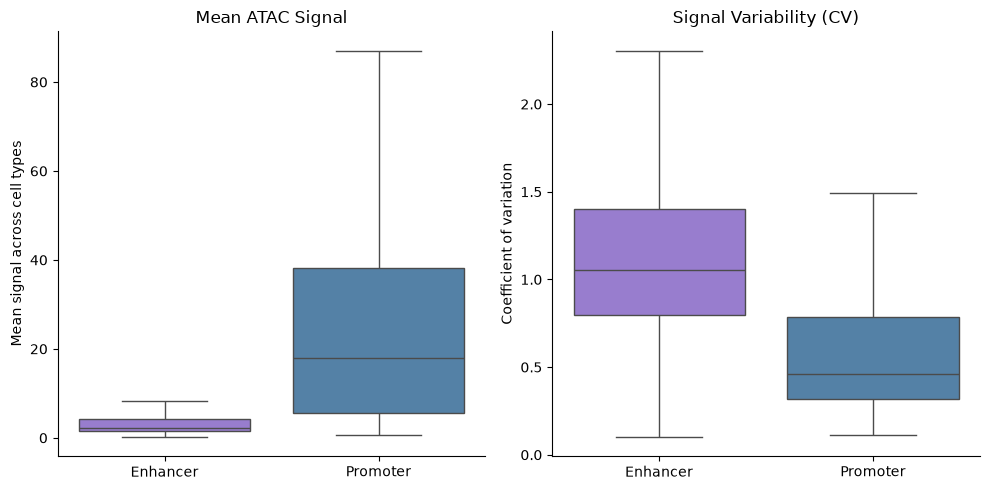

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Mean Signal
sns.boxplot(data=ATAC_pfiltered_extended, x='peak_type', y='mean_signal',
            palette={'Promoter': 'steelblue', 'Enhancer': 'mediumpurple'},
            showfliers=False, ax=axes[0])
axes[0].set_title("Mean ATAC Signal")
axes[0].set_xlabel("")
axes[0].set_ylabel("Mean signal across cell types")

# CV
sns.boxplot(data=ATAC_pfiltered_extended, x='peak_type', y='cv_signal',
            palette={'Promoter': 'steelblue', 'Enhancer': 'mediumpurple'},
            showfliers=False, ax=axes[1])
axes[1].set_title("Signal Variability (CV)")
axes[1].set_xlabel("")
axes[1].set_ylabel("Coefficient of variation")

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

#plt.suptitle("Promoter vs. Enhancer OCR accessibility: all Immune cells", fontsize=13, y=1.02)
plt.savefig('plots_for_poster/Boxplot CV Enhancer_promoter all cells.png', dpi=300)
plt.tight_layout()
plt.show()

C:\Users\lobe-\AppData\Local\Temp\ipykernel_24908\2224975031.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=ATAC_pfiltered_extended,


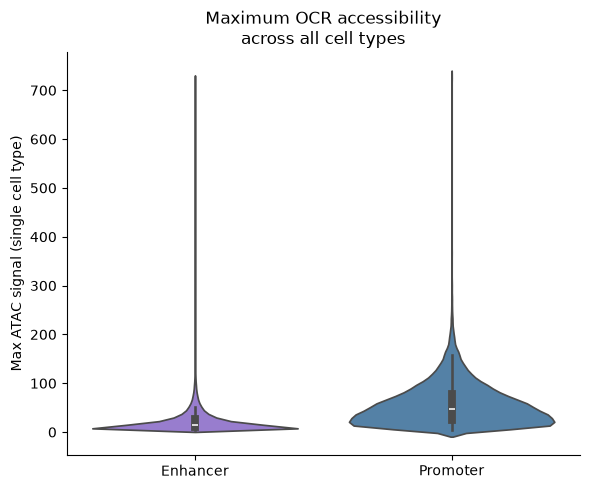

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Maximum Signal über alle Zelltypen pro Peak
ATAC_pfiltered_extended['max_signal'] = ATAC_pfiltered.iloc[:, 8:98].max(axis=1)

# Violinplot mit max_signal statt mean_signal
fig, ax = plt.subplots(figsize=(6, 5))
sns.violinplot(data=ATAC_pfiltered_extended, 
               x='peak_type', y='max_signal',
               palette={'Promoter': 'steelblue', 'Enhancer': 'mediumpurple'},
               inner='box', ax=ax)

ax.set_xlabel("")
ax.set_ylabel("Max ATAC signal (single cell type)")
ax.set_title("Maximum OCR accessibility\nacross all cell types")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
# Top 1% der Peaks pro Kategorie
top_enhancers = ATAC_pfiltered_extended[
    ATAC_pfiltered_extended['peak_type'] == 'Enhancer'
]['max_signal'].quantile(0.99)

top_promoters = ATAC_pfiltered_extended[
    ATAC_pfiltered_extended['peak_type'] == 'Promoter'
]['max_signal'].quantile(0.99)

print(f"Top 1% Enhancer max signal: {top_enhancers:.1f}")
print(f"Top 1% Promoter max signal: {top_promoters:.1f}")

Top 1% Enhancer max signal: 101.6
Top 1% Promoter max signal: 192.3


"While promoter OCRs show higher absolute chromatin accessibility than enhancer OCRs (top 1%: 192.3 vs. 101.6), enhancer OCRs exhibit greater signal variability across cell types (higher CV), consistent with their cell-type-specific activation patterns (Yoshida et al., 2019; Corces et al., 2018). This variability makes enhancers stronger discriminators of cell identity than promoters."

<h2> Calculating Std and Variance (promoter vs enhancer)

In [ ]:
std_promoters = ATAC_promoters.iloc[:,8:].std(axis=1) #Mittelwert jedem Signalpeak über alle Zellen hinweg
std_promoters.mean()

np.float64(9.735575860075166)

In [ ]:
std_enhancers = ATAC_enhancers.iloc[:,8:].std(axis=1) #Mittelwert jedem Signalpeak über alle Zellen hinweg
std_enhancers.mean()

np.float64(3.8733624583869357)

In [ ]:
var_promoters = ATAC_promoters.iloc[:,8:].var(axis=1) #Mittelwert jedem Signalpeak über alle Zellen hinweg
var_promoters.mean()

np.float64(143.22016480984846)

In [ ]:
var_enhancers = ATAC_enhancers.iloc[:,8:].var(axis=1) #Mittelwert jedem Signalpeak über alle Zellen hinweg
var_enhancers.mean()

np.float64(30.960503552413734)

In [ ]:
cv_enhancers = std_enhancers / mean_enhancers #Mittelwert jedem Signalpeak über alle Zellen hinweg
cv_enhancers.mean()

np.float64(1.1584095067846003)

In [ ]:
cv_promoters = std_promoters / mean_promoters #Mittelwert jedem Signalpeak über alle Zellen hinweg
cv_promoters.mean()

np.float64(0.6224775768891224)

**Ohne Log-Transformation: verzerrte, nicht-vergleichbare Werte bei der Std (und dann auch bei Variance)** <p>
Promoter werden in allen zelltypen eher häufiger ausgelesen als enhancer, weil sie konstitutiv offen sind, enhancer sind eher entweder offen oder gecshlossen (ausgelesen oder nicht ausgelesen).... Daher sollten Enhancer eine größer standardabweichung haben, weil enhancer halt entweder 0 oder viel abgelesen werden während promoter im durschnitt eher gleich häufig in zellen ausgelesen werden --> Enhancer sind ja viel mehr zelltyp spezifisch... <br> Der kleinere std-Werte bei enhancer hier liegt daran, dass wir keine log transformation gemacht haben. Enhancer haben an und für sich einfach kleinere ATAC signals werte,dadurch einfach per default kleinere werte für die std.

**ABER: CV (Coefficient of Variation) ist aussagekräftig** <p>
Da der CV das Verhältnis zwischen std und mean berechnt, kann man anhand von diesem wert gut sehen, wie sehr ENhancer vs Promoter abweichen. Den Erwartungen entsprechend schwanken die Enhancer Werte deutlich mehr als die Promoter Werte.

<b> Notiz an mich: 
+ nochmal bitte nur mit unseren Zellen machen
+ Var und Std nochmal mit Z-Transformation

<h3> Enhancer vs Promoter: ATAC-correlation between all celltypes

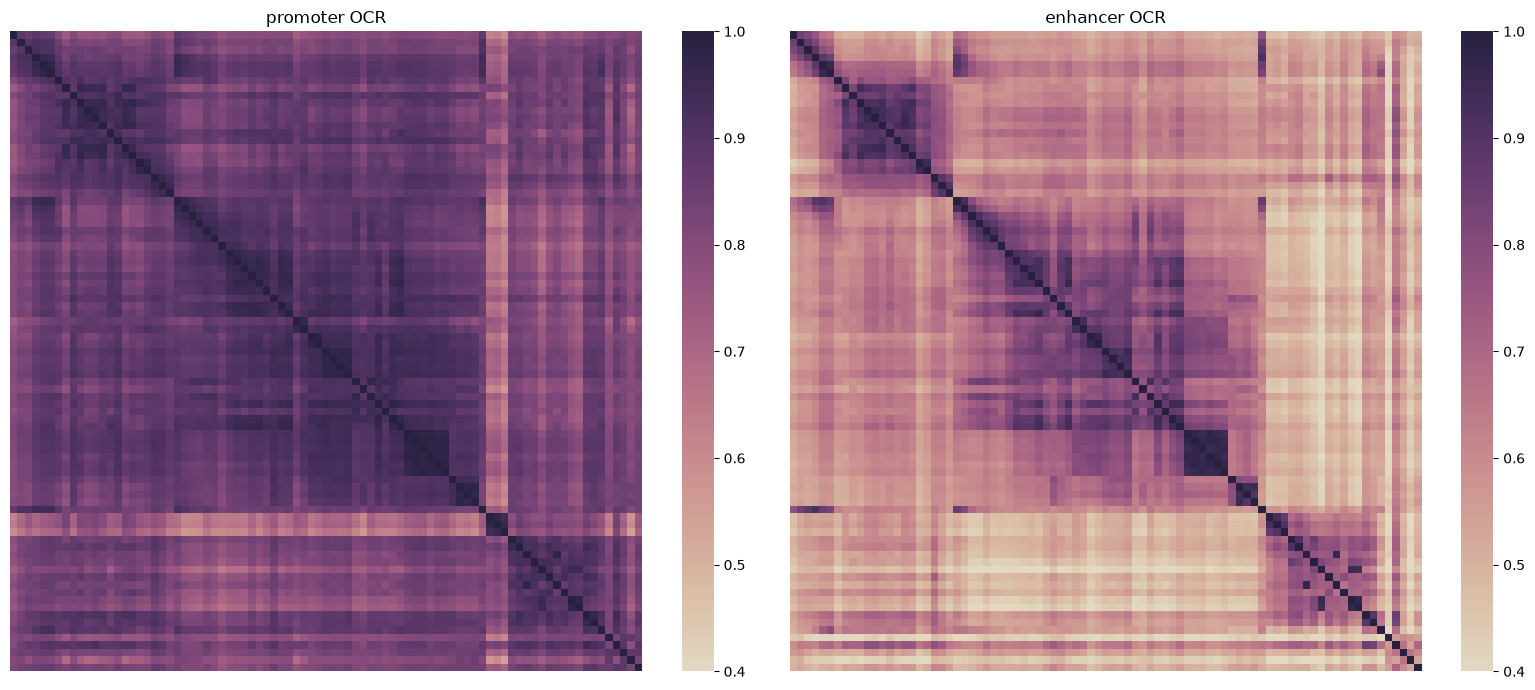

In [ ]:

corr_promoter = ATAC_promoters[signal_cols_all].corr(method='pearson')
corr_enhancer  = ATAC_enhancers[signal_cols_all].corr(method='pearson')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.heatmap(corr_promoter, cmap=sns.color_palette("ch:s=-.2,r=.6", as_cmap=True), vmin=0.4, vmax=1,
            ax=axes[0], xticklabels=False, yticklabels=False)
axes[0].set_title("promoter OCR")
sns.color_palette("ch:s=-.2,r=.6", as_cmap=True)


sns.heatmap(corr_enhancer, cmap=sns.color_palette("ch:s=-.2,r=.6", as_cmap=True), vmin=0.4, vmax=1,
            ax=axes[1], xticklabels=False, yticklabels=False)
axes[1].set_title("enhancer OCR")

plt.savefig('plots_for_poster/enhancer_promoter ATAC heatmap all cells.png', dpi= 300, bbox_inches='tight')
plt.tight_layout()
plt.show()

<h3> Enhancer vs Promoter: ATAC-correlation between tgd celltypes

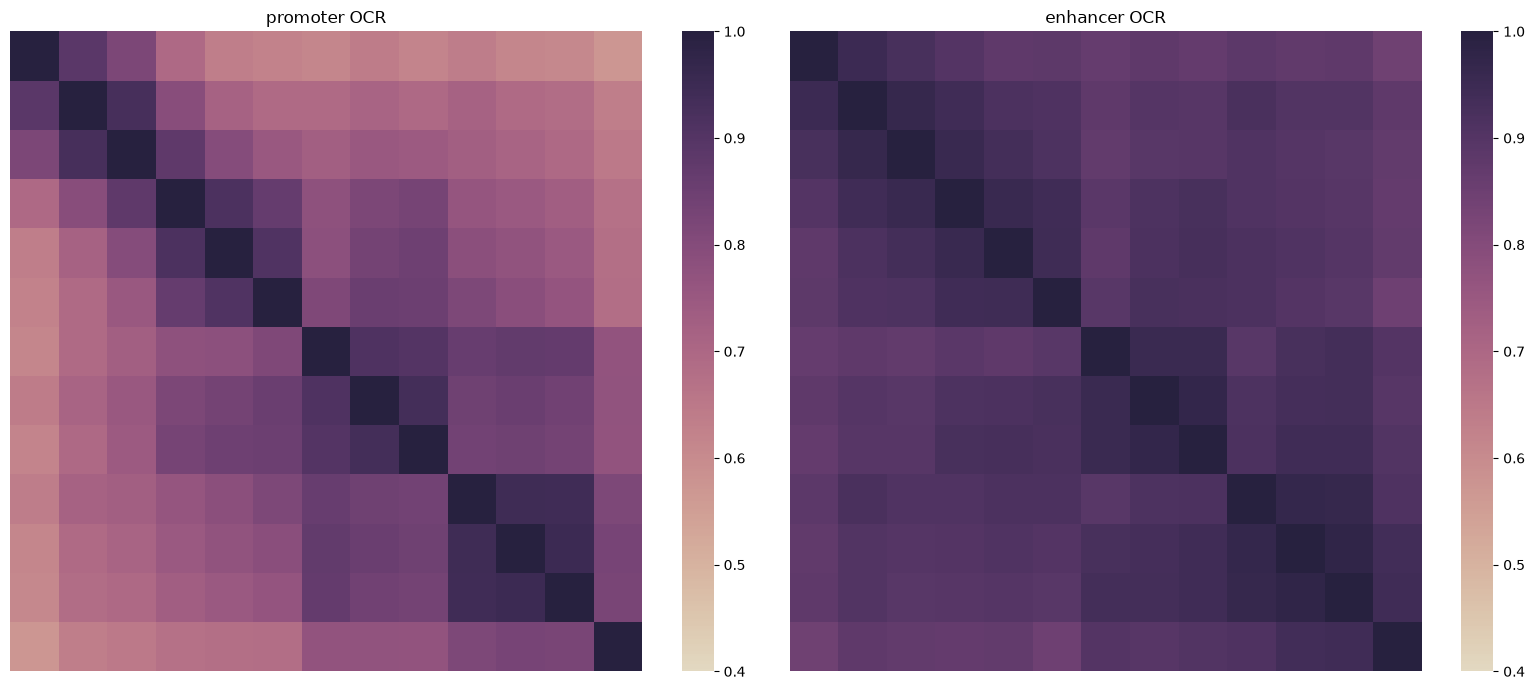

In [ ]:
ATAC_promoter_tgd = ATAC_Tgd[ATAC_Tgd["TSS"].isna()]
ATAC_enhancer_tgd = ATAC_Tgd[ATAC_Tgd["TSS"].notna()]

corr_promoter_tgd = ATAC_promoter_tgd[signal_cols_tgd].corr(method='pearson')
corr_enhancer_tgd  = ATAC_enhancer_tgd[signal_cols_tgd].corr(method='pearson')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.heatmap(corr_promoter_tgd, cmap=sns.color_palette("ch:s=-.2,r=.6", as_cmap=True), vmin=0.4, vmax=1,
            ax=axes[0], xticklabels=False, yticklabels=False)
axes[0].set_title("promoter OCR")

sns.heatmap(corr_enhancer_tgd, cmap=sns.color_palette("ch:s=-.2,r=.6", as_cmap=True), vmin=0.4, vmax=1,
            ax=axes[1], xticklabels=False, yticklabels=False)
axes[1].set_title("enhancer OCR")

plt.tight_layout()
plt.show()